<a href="https://colab.research.google.com/github/true-cpu/2001230346_HoangTuanKiet_ThucHanhDeepLearning/blob/main/Buoi4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# List the contents of the newly extracted directory
!ls -R "{zip_extraction_dir}"

/content/extracted_zip_data:
test  train

/content/extracted_zip_data/test:
test

/content/extracted_zip_data/test/test:
false  true

/content/extracted_zip_data/test/test/false:
100.png  157.png  212.png  269.png  324.png  380.png  436.png  492.png	548.png
101.png  158.png  213.png  26.png   325.png  381.png  437.png  493.png	549.png
102.png  159.png  214.png  270.png  326.png  382.png  438.png  494.png	54.png
103.png  15.png   215.png  271.png  327.png  383.png  439.png  495.png	550.png
104.png  160.png  216.png  272.png  328.png  384.png  43.png   496.png	551.png
105.png  161.png  217.png  273.png  329.png  385.png  440.png  497.png	552.png
106.png  162.png  218.png  274.png  32.png   386.png  441.png  498.png	553.png
107.png  163.png  219.png  275.png  330.png  387.png  442.png  499.png	554.png
108.png  164.png  21.png   276.png  331.png  388.png  443.png  49.png	555.png
109.png  165.png  220.png  277.png  332.png  389.png  444.png  4.png	556.png
10.png	 166.png  221.png  278.png  

In [16]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# Define the base directory where the zip file was extracted
base_data_dir = '/content/extracted_zip_data'

# Define paths for training and testing data
# Based on the `ls -R` output, the structure is: extracted_zip_data/train/train/{false,true}
# and extracted_zip_data/test/test/{false,true}
train_dir = os.path.join(base_data_dir, 'train', 'train')
test_dir = os.path.join(base_data_dir, 'test', 'test')

print(f"Training data directory: {train_dir}")
print(f"Testing data directory: {test_dir}")

# Check if the directories exist
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
if not os.path.exists(test_dir):
    print(f"Error: Testing directory not found at {test_dir}")

Training data directory: /content/extracted_zip_data/train/train
Testing data directory: /content/extracted_zip_data/test/test


Next, we'll use `ImageDataGenerator` to preprocess the images. This includes scaling pixel values and can optionally include data augmentation techniques to improve model robustness. We'll set up separate generators for training and testing data.

In [17]:
# Image dimensions
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Create data generators

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=20,          # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,      # Randomly shift images horizontally
    height_shift_range=0.2,     # Randomly shift images vertically
    shear_range=0.2,            # Apply shear transformations
    zoom_range=0.2,             # Apply random zoom
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'         # Fill in new pixels created by transformations
)

# Test data generator (only rescaling, no augmentation for consistent evaluation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches from directory 'train_dir'
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' because we have two classes (false/true)
)

# Flow validation images in batches from directory 'test_dir'
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 4438 images belonging to 2 classes.
Found 1114 images belonging to 2 classes.


In [18]:
# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5), # Dropout for regularization to prevent overfitting
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Now, let's train the CNN model using the `train_generator` and evaluate it using the `test_generator`.

In [19]:
# Train the model
EPOCHS = 10  # You can adjust the number of epochs

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

print("\nModel training complete.")

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.5093 - loss: 0.7172 - val_accuracy: 0.5009 - val_loss: 0.6902
Epoch 2/10
  1/138 ━━━━━━━━━━━━━━━━━━━━ 2:58 1s/step - accuracy: 0.5938 - loss: 0.6978

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.5938 - loss: 0.6978 - val_accuracy: 0.5009 - val_loss: 0.6904
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.5422 - loss: 0.6906 - val_accuracy: 0.5460 - val_loss: 0.6883
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.5938 - loss: 0.6957 - val_accuracy: 0.5515 - val_loss: 0.6880
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.5368 - loss: 0.6900 - val_accuracy: 0.5267 - val_loss: 0.6902
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.5938 - loss: 0.7008 - val_accuracy: 0.5276 - val_loss: 0.6898
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.5318 - loss: 0.6908 - val_accuracy: 0.5432 - val_loss: 0.6873
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.5625 - loss: 0.6784 - val_accuracy: 0.5496 - val_loss: 0.6867
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.5279 - loss: 0.6909 - val_accurac

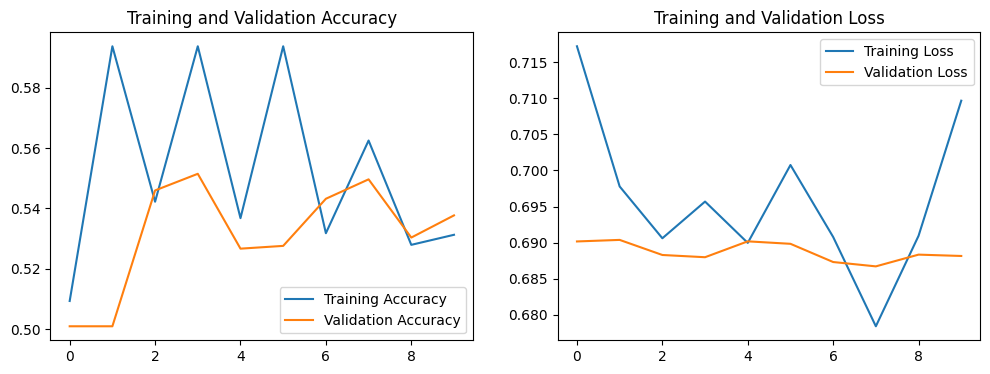

In [23]:
# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

Since the previous transfer learning setup was removed, let's regenerate the code to use MobileNetV2 for improved image classification. We will freeze its base layers and add new classification layers.

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load the MobileNetV2 model pre-trained on ImageNet, without the top classification layer
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the convolutional base to prevent its weights from being updated during training
base_model.trainable = False

# Create a new model on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Convert features to a single vector
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

model_transfer = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model
model_transfer.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

model_transfer.summary()
print("\nTransfer learning model setup complete.")

/tmp/ipykernel_9068/4031054568.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Transfer learning model setup complete.


In [25]:
# Train the transfer learning model
EPOCHS_TRANSFER = 10 # You can adjust the number of epochs for transfer learning

history_transfer = model_transfer.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS_TRANSFER,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

print("\nTransfer learning model training complete.")

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 133s 911ms/step - accuracy: 0.5606 - loss: 0.7238 - val_accuracy: 0.5818 - val_loss: 0.6562
Epoch 2/10
  1/138 ━━━━━━━━━━━━━━━━━━━━ 1:08 502ms/step - accuracy: 0.5000 - loss: 0.7481

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.5000 - loss: 0.7481 - val_accuracy: 0.5864 - val_loss: 0.6564
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 185s 936ms/step - accuracy: 0.5928 - loss: 0.6680 - val_accuracy: 0.6397 - val_loss: 0.6362
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 292ms/step - accuracy: 0.6562 - loss: 0.5910 - val_accuracy: 0.6415 - val_loss: 0.6357
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6044 - loss: 0.6566 - val_accuracy: 0.6507 - val_loss: 0.6301
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.4688 - loss: 0.8729 - val_accuracy: 0.6526 - val_loss: 0.6269
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 165s 900ms/step - accuracy: 0.6232 - loss: 0.6526 - val_accuracy: 0.6461 - val_loss: 0.6264
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - accuracy: 0.5625 - loss: 0.6317 - val_accuracy: 0.6507 - val_loss: 0.6249
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6162 - loss: 0.6483 - val_a

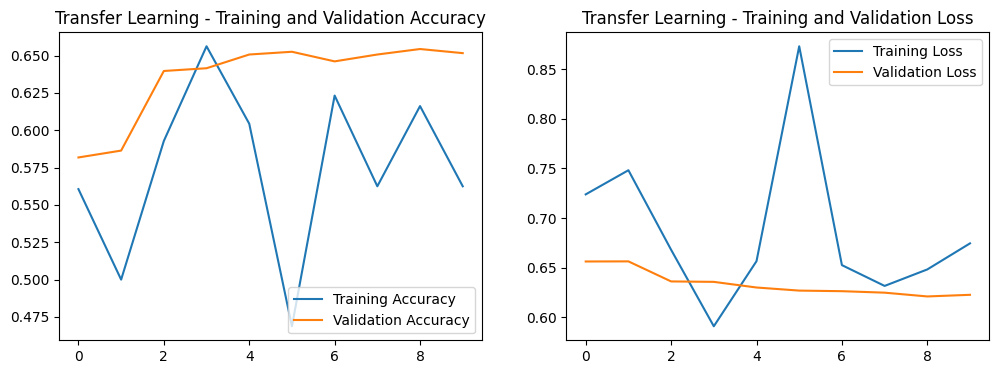

In [26]:
# Plot training history for transfer learning model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Transfer Learning - Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Transfer Learning - Training and Validation Loss')

plt.show()

In [27]:
# Evaluate the transfer learning model on the test data
loss_transfer, accuracy_transfer = model_transfer.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print(f"\nTransfer Learning Test Loss: {loss_transfer:.4f}")
print(f"Transfer Learning Test Accuracy: {accuracy_transfer:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 640ms/step - accuracy: 0.6535 - loss: 0.6221

Transfer Learning Test Loss: 0.6221
Transfer Learning Test Accuracy: 0.6535


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


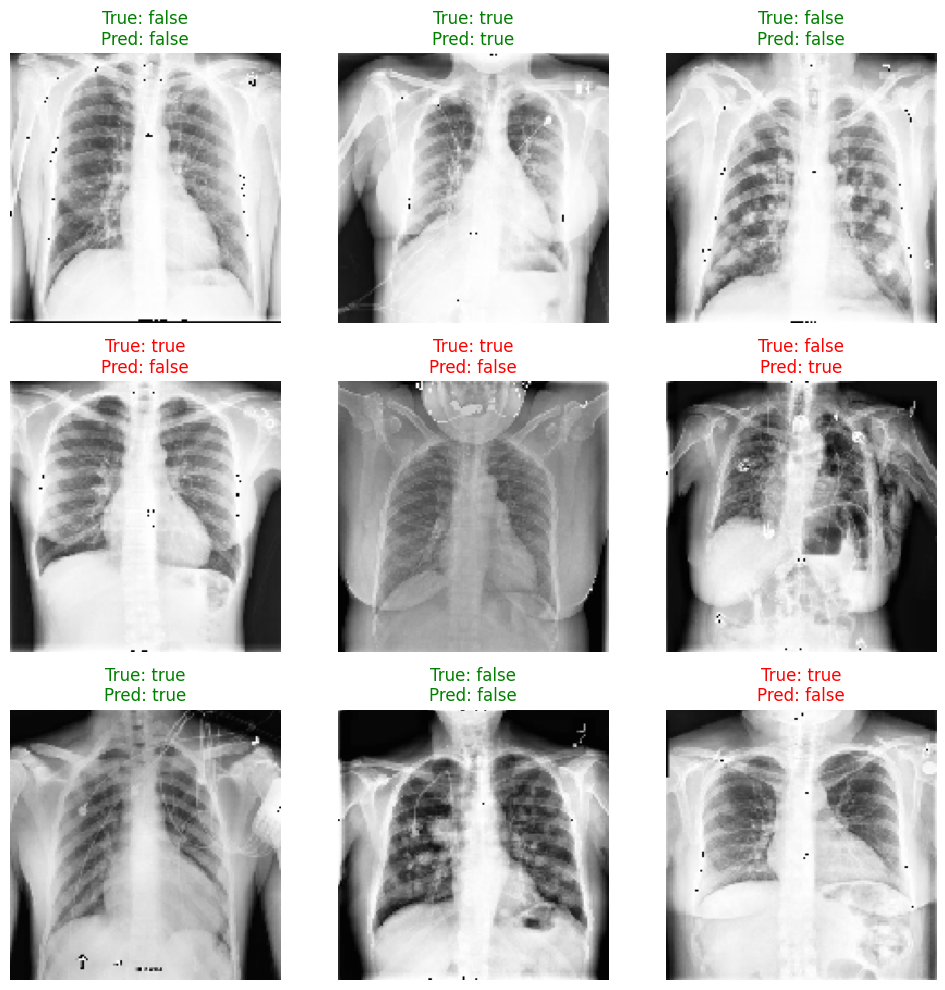


Displayed sample predictions from the test set.


In [28]:
# Get a batch of test images and labels
# Ensure test_generator is reset to get consistent batches from the start
test_generator.reset()
X_test, y_test = next(test_generator)

# Make predictions
predictions = model_transfer.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)

# Map class indices to class names
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 10))
for i in range(min(9, len(X_test))): # Display up to 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    true_label = class_names[int(y_test[i])]
    predicted_label = class_names[predicted_classes[i][0]]
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("\nDisplayed sample predictions from the test set.")